Import

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/otomoto_all_data.csv")

In [2]:
print("Shape: ", df.shape, "\n\n")

df.head()

Shape:  (176812, 31) 




,link,title,description,image_urls,price,currency,location_city,location_district,location_voivodeship,year,...,damaged,condition,drive,seats,origin,accident_free,first_owner,registered_pl,version,has_registration
0,https://www.otomoto.pl/osobowe/oferta/bmw-x2-I...,BMW X2,BMW X2\n– Najnowsza generacja SUV-a z 2025 rok...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,113900.0,PLN,Grudziądz,Grudziądz,Kujawsko-pomorskie,2025.0,...,Yes,Używany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.otomoto.pl/osobowe/oferta/audi-q5-...,Audi Q5,"Kontakt Opiekun oferty tel\nWyświetl numer\n, ...",https://ireland.apollo.olxcdn.com/v1/files/eyJ...,183500.0,PLN,Bydgoszcz,Bydgoszcz,Kujawsko-pomorskie,2023.0,...,NaN,Używany,4x4 (dołączany automatycznie),5.0,Polska,Yes,Yes,Yes,NaN,NaN
2,https://www.otomoto.pl/osobowe/oferta/volvo-xc...,Volvo XC 60 T8 AWD Recharge Geartronic RDesign,"Volvo XC-60 2024, sprowadzony, stan uszkodzony...",https://ireland.apollo.olxcdn.com/v1/files/eyJ...,89900.0,PLN,Dzięcielin,Dzięcielin,Wielkopolskie,2024.0,...,Yes,Używany,4x4 (stały),NaN,NaN,NaN,NaN,NaN,T8 AWD Recharge Geartronic RDesign,Yes
3,https://www.otomoto.pl/osobowe/oferta/bmw-seri...,BMW Seria 3,Dealer BMW i MINI Bawaria Motors Janki\nserdec...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,192900.0,PLN,Falenty,Falenty,Mazowieckie,2023.0,...,NaN,Używany,4x4 (stały),5.0,Polska,Yes,Yes,Yes,NaN,NaN
4,https://www.otomoto.pl/osobowe/oferta/fiat-tip...,Fiat Tipo 1.6 MultiJet Sport,"Fiat Tipo 2020 rok, kombi, sprowadzony, ekonom...",https://ireland.apollo.olxcdn.com/v1/files/eyJ...,29000.0,PLN,Konin,Konin,Wielkopolskie,2020.0,...,NaN,Używany,Na przednie koła,5.0,NaN,NaN,NaN,NaN,1.6 MultiJet Sport,Yes


Duplicates and missing values

In [3]:
print("\nDuplicated links: ", df['link'].duplicated().sum())
print("\nDuplicates: ", df.duplicated().sum())


Duplicated links:  0

Duplicates:  0


In [4]:
# If we use just simple print, IDE will cut off long output. Since we want to see all columns with missing values, we have to save them to csv file and open it here
df.isnull().sum().to_csv('missing_values.csv')

print("Saved missing_values.csv.")

missing_values = pd.read_csv('missing_values.csv', index_col=0, header=None, names=['column', 'missing_count'])
missing_values

Saved missing_values.csv.


,missing_count
column,
NaN,0
link,0
title,0
description,708
image_urls,215
price,0
currency,0
location_city,14
location_district,33035


Everything loaded correctly! We also have no duplicates!

Let's check currencies of offers and transfer them into PLN!

In [5]:
eur_mask = df['currency'] == 'EUR'

eur_sample_indices = df.index[eur_mask][:5].tolist()

print("Sample indices:", eur_sample_indices)

cols_to_check = ['price', 'currency', 'brand', 'model']

print("\n--- 1. Before change(Original)) ---")
if eur_sample_indices:
    display(df.loc[eur_sample_indices, cols_to_check])
else:
    print("No cars in EUR!")

Sample indices: [873, 2067, 9158, 9359, 9795]

--- 1. Before change(Original)) ---


,price,currency,brand,model
873,586735.0,EUR,Ferrari,12Cilindri
2067,46900.0,EUR,Ford,Tourneo Custom
9158,79827.0,EUR,Porsche,718 Boxster
9359,22500.0,EUR,Volvo,V60
9795,3500.0,EUR,Peugeot,308


In [6]:
EXCHANGE_RATE = 4.20 # For 22.02.2026

if eur_sample_indices:
    df.loc[eur_mask, 'price'] = df.loc[eur_mask, 'price'] * EXCHANGE_RATE
    df.loc[eur_mask, 'currency'] = 'PLN'
    print("\nExchange rate applied.")


Exchange rate applied.


In [7]:
print("\n--- 2. After change (verification) ---")
if eur_sample_indices:
    display(df.loc[eur_sample_indices, cols_to_check])


--- 2. After change (verification) ---


,price,currency,brand,model
873,2464287.0,PLN,Ferrari,12Cilindri
2067,196980.0,PLN,Ford,Tourneo Custom
9158,335273.4,PLN,Porsche,718 Boxster
9359,94500.0,PLN,Volvo,V60
9795,14700.0,PLN,Peugeot,308


In [8]:
df.describe()

,price,year,mileage_km,engine_capacity_cm3,power_hp,doors,seats
count,1.768120e+05,176812.000000,1.766620e+05,173391.000000,176613.000000,175981.000000,161372.000000
mean,9.257204e+04,2017.120823,1.280468e+05,18765.869607,173.909180,4.737477,5.073978
std,1.248420e+05,6.415735,9.684480e+04,7564.341717,93.642068,0.649900,0.747143
min,4.000000e+02,1922.000000,1.000000e+00,652.000000,1.000000,2.000000,1.000000
25%,2.989000e+04,2013.000000,4.400000e+04,14823.000000,117.000000,5.000000,5.000000
50%,5.870000e+04,2018.000000,1.260000e+05,17963.000000,150.000000,5.000000,5.000000
75%,1.149000e+05,2022.000000,1.930000e+05,19953.000000,195.000000,5.000000,5.000000
max,8.400000e+06,2026.000000,2.978700e+06,84003.000000,1665.000000,6.000000,9.000000


Data Cleaning

In [9]:
df['location_voivodeship'].value_counts()

location_voivodeship
Mazowieckie      34093
Wielkopolskie    23127
Śląskie          22652
Małopolskie      15885
Dolnośląskie     12952
                 ...  
Praga                1
Granice              1
Dąbrowa              1
Cisowa               1
Paniowy              1
Name: count, Length: 149, dtype: int64

In [51]:
wrong_voivodeships_map = ~df['location_voivodeship'].isin(
    [
    'Dolnośląskie',
    'Kujawsko-pomorskie',
    'Lubelskie',
    'Lubuskie',
    'Łódzkie',
    'Małopolskie',
    'Mazowieckie',
    'Opolskie',
    'Podkarpackie',
    'Podlaskie',
    'Pomorskie',
    'Śląskie',
    'Świętokrzyskie',
    'Warmińsko-mazurskie',
    'Wielkopolskie',
    'Zachodniopomorskie'
]
)

print("Wrong voivodeships count: ", wrong_voivodeships_map.sum())

df.loc[wrong_voivodeships_map, 'location_voivodeship'] = np.nan

print("\n\nAfter correction:")
df[wrong_voivodeships_map]

Wrong voivodeships count:  1648


After correction:


,link,title,description,image_urls,price,currency,location_city,location_district,location_voivodeship,year,...,damaged,condition,drive,seats,origin,accident_free,first_owner,registered_pl,version,has_registration
64,https://www.otomoto.pl/osobowe/oferta/bmw-m6-I...,BMW M6,"BMW M6 5.0 V10, rok produkcji 2007, silnik ben...",https://ireland.apollo.olxcdn.com/v1/files/eyJ...,39900.0,PLN,Industriezone Klus 10,4710 Balsthal,NaN,2007.0,...,Yes,Używany,Na tylne koła,NaN,Szwajcaria,NaN,NaN,NaN,NaN,NaN
134,https://www.otomoto.pl/osobowe/oferta/jeep-wra...,Jeep Wrangler,Posiadam na sprzedaż Jeep Wrangler Rubicon wer...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,389000.0,PLN,Oleśnica,NaN,NaN,2024.0,...,NaN,Używany,4x4 (stały),5.0,Stany Zjednoczone,Yes,Yes,Yes,NaN,Yes
222,https://www.otomoto.pl/osobowe/oferta/volkswag...,Volkswagen Passat Variant 2.0 TDI Comfortline,Do sprzedania posiadam sprowadzonego z Niemiec...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,31999.0,PLN,Będzin,NaN,NaN,2014.0,...,NaN,Używany,Na przednie koła,5.0,NaN,NaN,NaN,NaN,2.0 TDI Comfortline,Yes
265,https://www.otomoto.pl/osobowe/oferta/bmw-x3-I...,BMW X3 xDrive28i xLine,Na sprzedaż wystawiam moje\nBMW X3 F25 xDrive2...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,56999.0,PLN,Czeladź,NaN,NaN,2015.0,...,NaN,Używany,NaN,5.0,NaN,NaN,NaN,NaN,xDrive28i xLine,Yes
285,https://www.otomoto.pl/osobowe/oferta/toyota-i...,Toyota iQ 1.0 Sol,Sprzedam TOYOTĘ IQ z silnikiem benzynowym w ko...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,13950.0,PLN,Mikołów,NaN,NaN,2009.0,...,NaN,Używany,Na przednie koła,4.0,Niemcy,NaN,NaN,Yes,1.0 Sol,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176317,https://www.otomoto.pl/osobowe/oferta/fiat-500...,Fiat 500 1.2 by Gucci,Sprzedam\nFiat 500\nWersja individual\nSilnik ...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,19999.0,PLN,Zawiercie,NaN,NaN,2012.0,...,NaN,Używany,Na przednie koła,NaN,NaN,NaN,NaN,NaN,1.2 by Gucci,Yes
176486,https://www.otomoto.pl/osobowe/oferta/mazda-6-...,Mazda 6 2.0 Skyenergy,Mazda 6 Salon polska 2 właściciel\nUdokumentow...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,36900.0,PLN,Mikołów,NaN,NaN,2013.0,...,NaN,Używany,Na przednie koła,5.0,Polska,Yes,NaN,Yes,2.0 Skyenergy,Yes
176505,https://www.otomoto.pl/osobowe/oferta/hyundai-...,Hyundai i40 i40cw 1.7 CRDi Automatik Fifa Worl...,"! ! NA WSTĘPIE,PROSZĘ NIE PORÓWNYWAĆ TEGO SAMO...",https://ireland.apollo.olxcdn.com/v1/files/eyJ...,34900.0,PLN,Zawiercie,NaN,NaN,2015.0,...,NaN,Używany,Na przednie koła,NaN,NaN,NaN,NaN,NaN,i40cw 1.7 CRDi Automatik Fifa World Cup Editio...,Yes
176578,https://www.otomoto.pl/osobowe/oferta/mercedes...,Mercedes-Benz GLK,"Jeden właściciel, kpl kluczyków, pełna histori...",https://ireland.apollo.olxcdn.com/v1/files/eyJ...,29900.0,PLN,Mikołów,NaN,NaN,2009.0,...,Yes,Używany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes


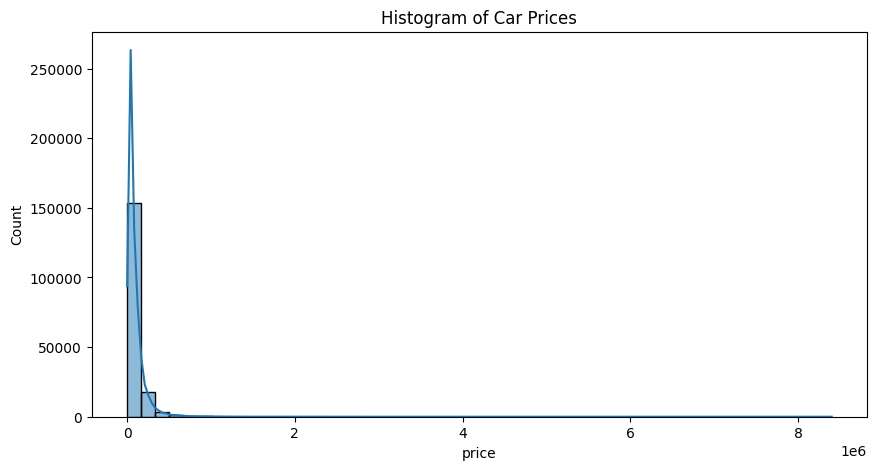

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Histogram of Car Prices')
plt.show()

In [54]:
print("The most expensive cars:")
rich_cars = df[df['price'] > 1_000_000][['brand', 'model', 'price', 'year']]
display(rich_cars.sort_values(by='price', ascending=False).head(10))

The most expensive cars:


,brand,model,price,year
145475,Aston Martin,One-77,8400000.0,2012.0
150326,Ferrari,812 Superfast,8265600.0,2022.0
37334,Audi,A3 Sportback,5999999.0,2016.0
95297,Ferrari,Purosangue,3360000.0,2025.0
34747,Ferrari,SF90 Spider,3185952.0,2022.0
154019,Ferrari,Purosangue,3157077.0,2025.0
159946,Ferrari,Purosangue,3155460.0,2024.0
143518,Ferrari,Purosangue,3134569.2,2025.0
47745,Ferrari,12Cilindri,3099083.4,2025.0
117025,Ferrari,Purosangue,3087000.0,2025.0


In [55]:
print("The cheapest cars:")
cheap_cars = df[df['price'] < 1000][['brand', 'model', 'price', 'description']]
display(cheap_cars.head(10))

The cheapest cars:


,brand,model,price,description
21149,Chevrolet,Matiz,999.0,Witam. Sprzedam Matiza. Cena 999zł. Więcej inf...
35293,Skoda,Octavia,700.0,Wita.\nAuto na części - Skoda Octavia I Lift 1...
39451,Daihatsu,Cuore,950.0,SYNDYK MASY UPADŁOŚCI ZAPRASZA DO SKŁADANIA OF...
89039,Fiat,Bravo,998.0,[\nEdit:\nwidzę że sporo osób obserwuje ofertę...
155412,Volkswagen,Golf,890.0,Auta uszkodzone jak na zdjęciach\nMożliwość sp...
158912,Opel,Corsa,500.0,"Pojazd o niskich kosztach eksploatacji, tani w..."
168084,Seat,Ibiza,400.0,"Masz już starą, brudzącą się kierownicę, albo ..."


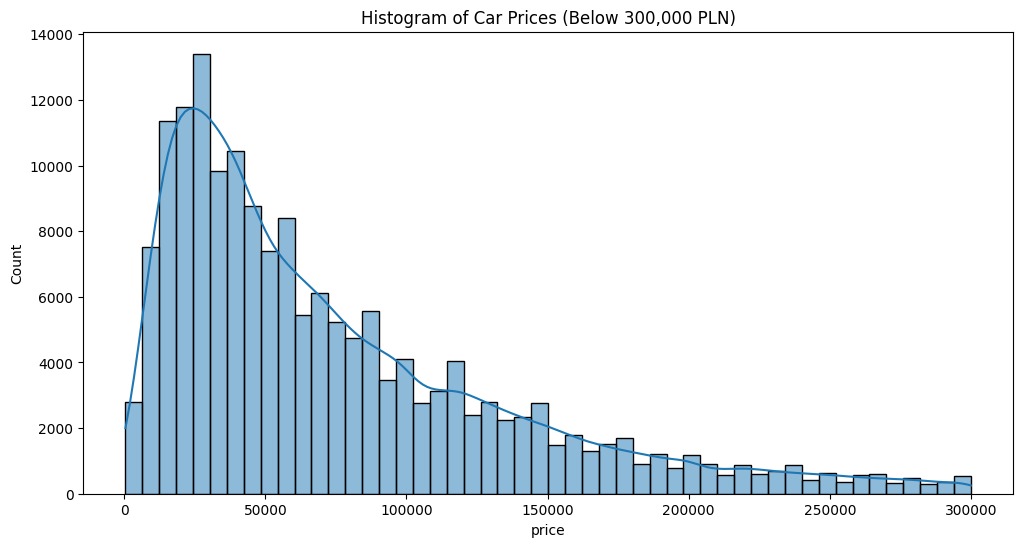

In [56]:
plt.figure(figsize=(12, 6))
# Focus on prices below 300,000 PLN
subset = df[df['price'] < 300_000]
sns.histplot(subset['price'], bins=50, kde=True)
plt.title('Histogram of Car Prices (Below 300,000 PLN)')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

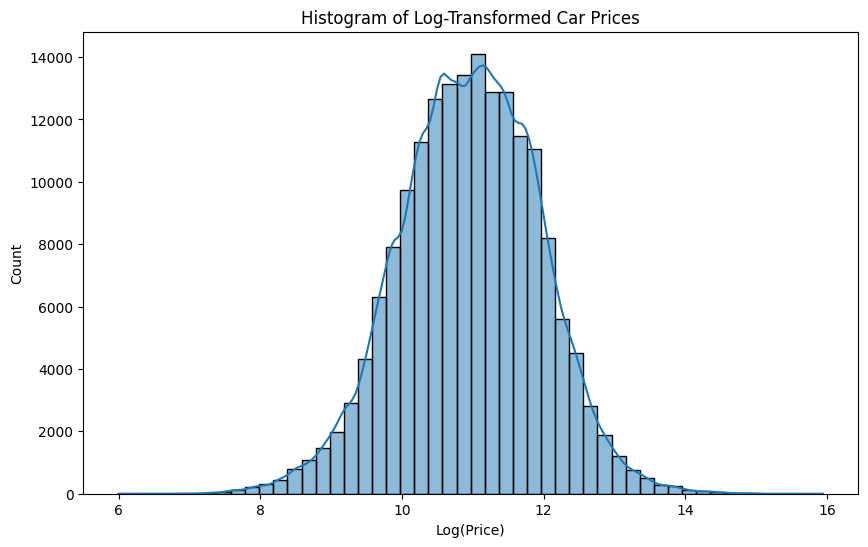

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['price']), kde=True, bins=50)
plt.title('Histogram of Log-Transformed Car Prices')
plt.xlabel('Log(Price)')
plt.show()

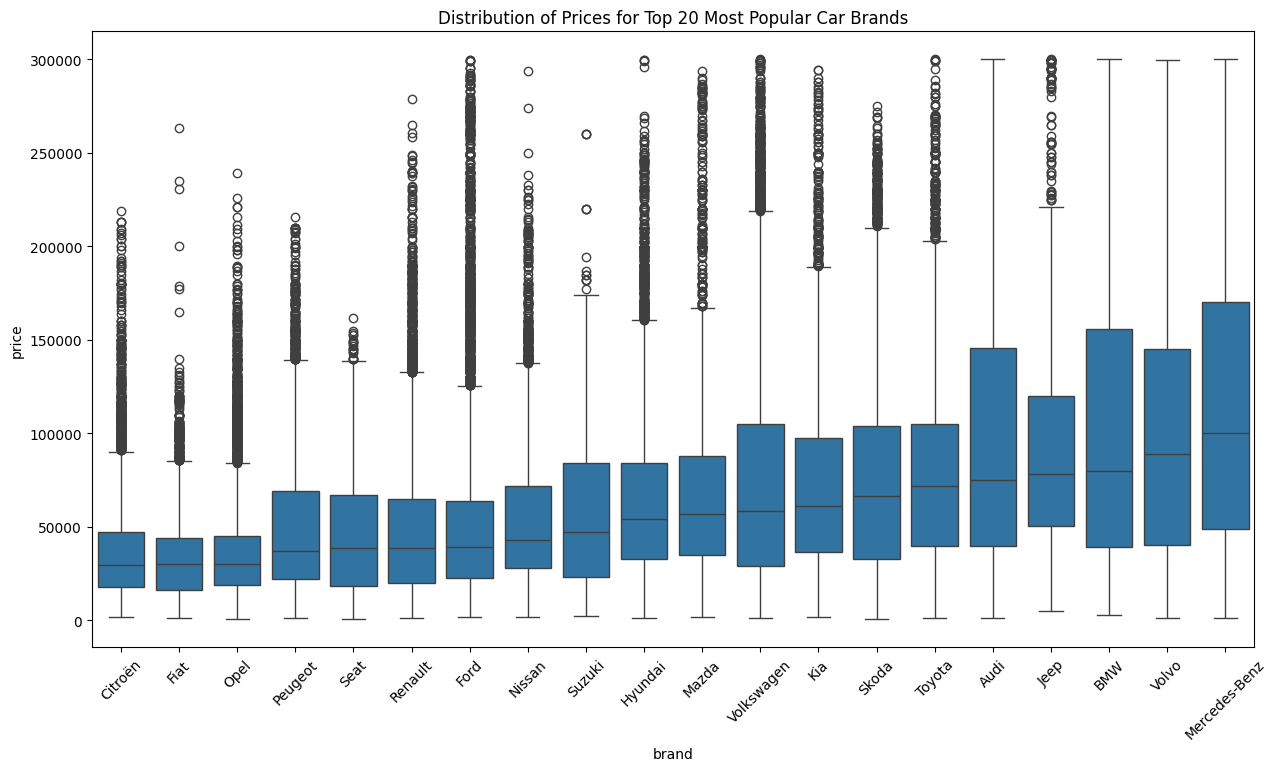

In [58]:
plt.figure(figsize=(15, 8))

# 1. Find Top 20 most popular brands
top_brands = df['brand'].value_counts().head(20).index

# 2. Filter data to only these brands and prices below 300,000 PLN
df_top = df[ (df['brand'].isin(top_brands)) & (df['price'] < 300_000) ]

# 3. Draw boxplot
# order=... sorts brands by median price
my_order = df_top.groupby(by=["brand"])["price"].median().sort_values().index

sns.boxplot(x='brand', y='price', data=df_top, order=my_order)
plt.xticks(rotation=45)
plt.title('Distribution of Prices for Top 20 Most Popular Car Brands')
plt.show()

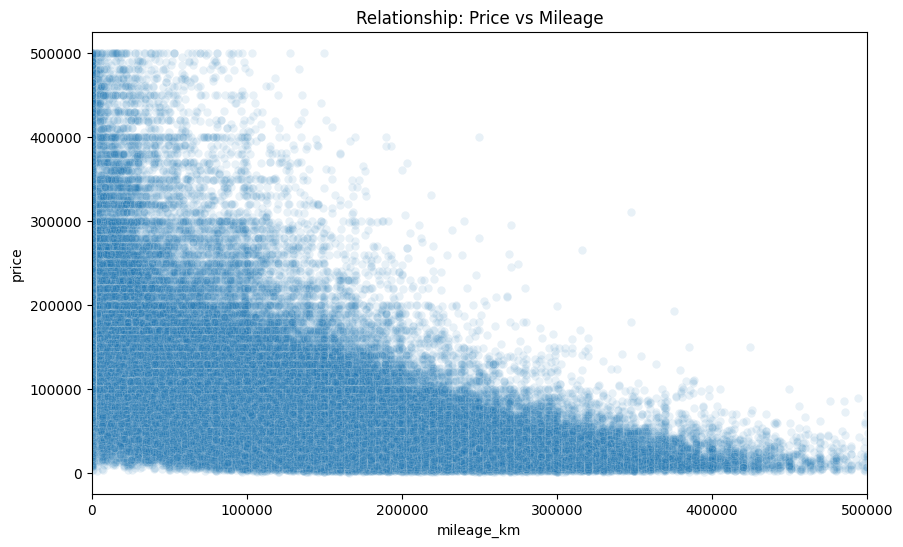

In [59]:
plt.figure(figsize=(10, 6))

# Alpha=0.1 to see where points overlap (density)
sns.scatterplot(x='mileage_km', y='price', data=df[df['price'] < 500_000], alpha=0.1)

plt.title('Relationship: Price vs Mileage')
plt.xlim(0, 500_000) # X axis limit to 500k km
plt.show()

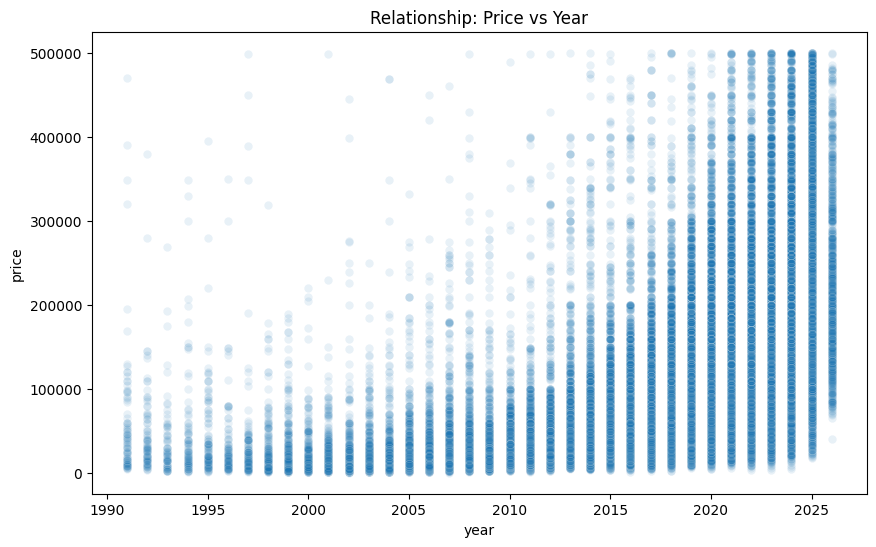

In [60]:
plt.figure(figsize=(10, 6))

df_year = df[(df['year'] > 1990) & (df['price'] < 500_000)]

sns.scatterplot(x='year', y='price', data=df_year, alpha=0.1)
plt.title('Relationship: Price vs Year')
plt.show()

In [61]:
df.to_csv("../data/processed/otomoto_all_data_cleaned.csv", index=False)